Preprocessing 1: Setup



Mounted at /content/drive
✓ Google Drive mounted
Installing minimal packages...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 30.8 MB/s eta 0:00:00
✓ Packages installed
✓ Basic libraries loaded
  NumPy: 2.0.2
  SoundFile: 0.13.1
✓ Created: /content/drive/MyDrive/Electric Sheep/Beliz - EDA/data/processed
✓ Loaded 440 recordings
  Contexts: {'I': 221, 'B': 127, 'F': 92}
  Distress labels: {1: 221, 0: 219}

TESTING AUDIO LOADING (SOUNDFILE)

Test file: F_CAN01_EU_FN_GIA01_202.wav
✓ Audio loaded successfully with soundfile!
  Sample rate: 8000 Hz
  Duration: 1.896 seconds
  Samples: 15,169
  Amplitude range: [-0.0256, 0.0217]


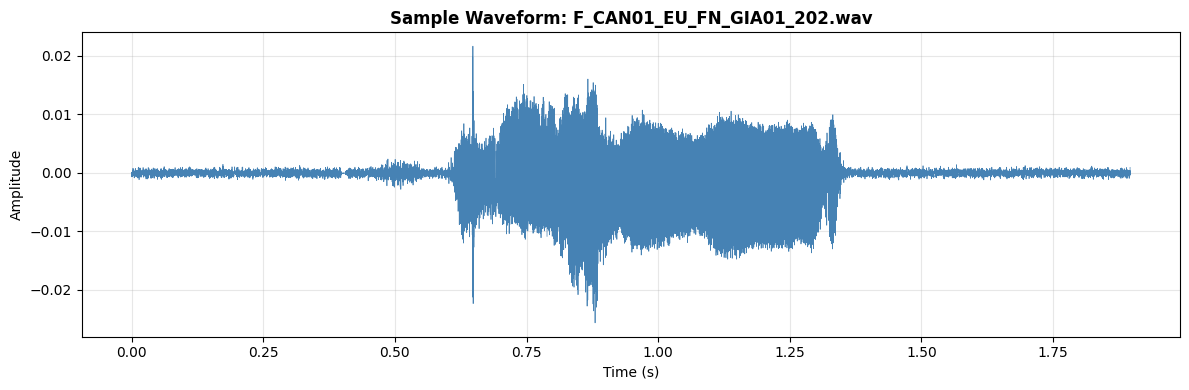


✓ Figure saved: preprocessing_00_audio_verification.png


In [1]:
# Google Colab Setup
try:
    import google.colab
    from google.colab import drive
    drive.mount('/content/drive')
    print("✓ Google Drive mounted")
except:
    print("✓ Running locally")

# Your path
GDRIVE_BASE = '/content/drive/MyDrive/Electric Sheep/Beliz - EDA'

# %%
# Install ONLY what we need, avoid librosa completely for now
print("Installing minimal packages...")
!pip install -q soundfile scipy resampy
print("✓ Packages installed")

# %%
# Import WITHOUT librosa initially
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import soundfile as sf
from pathlib import Path
from tqdm import tqdm
from scipy import signal
import resampy
import warnings
warnings.filterwarnings('ignore')

print("✓ Basic libraries loaded")
print(f"  NumPy: {np.__version__}")
print(f"  SoundFile: {sf.__version__}")

# %%
# Setup paths
PROJECT_ROOT = Path(GDRIVE_BASE)
DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
print(f"✓ Created: {PROCESSED_DATA_DIR}")

# %%
# Load metadata
metadata_path = DATA_DIR / "metadata_with_audio_props.csv"
if not metadata_path.exists():
    metadata_path = DATA_DIR / "metadata.csv"

df = pd.read_csv(metadata_path)
print(f"✓ Loaded {len(df)} recordings")
print(f"  Contexts: {df['context'].value_counts().to_dict()}")
print(f"  Distress labels: {df['distress_label'].value_counts().to_dict()}")

# %%
# Test audio loading with soundfile (NOT librosa)
print(f"\n{'='*70}")
print("TESTING AUDIO LOADING (SOUNDFILE)")
print(f"{'='*70}")

test_file = df.sample(1).iloc[0]
print(f"\nTest file: {test_file['filename']}")

try:
    # Use soundfile instead of librosa
    y, sr = sf.read(test_file['file_path'])

    # Handle stereo (convert to mono by averaging channels)
    if len(y.shape) > 1:
        y = np.mean(y, axis=1)

    duration = len(y) / sr

    print(f"✓ Audio loaded successfully with soundfile!")
    print(f"  Sample rate: {sr} Hz")
    print(f"  Duration: {duration:.3f} seconds")
    print(f"  Samples: {len(y):,}")
    print(f"  Amplitude range: [{y.min():.4f}, {y.max():.4f}]")

    # Simple visualization
    fig, ax = plt.subplots(1, 1, figsize=(12, 4))

    time = np.linspace(0, duration, len(y))
    ax.plot(time, y, linewidth=0.5, color='steelblue')
    ax.set_title(f'Sample Waveform: {test_file["filename"]}', fontweight='bold')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'preprocessing_00_audio_verification.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n✓ Figure saved: preprocessing_00_audio_verification.png")

except Exception as e:
    print(f" Error: {e}")
    import traceback
    traceback.print_exc()

DURATION ANALYSIS

Duration Statistics:
  Count: 440
  Mean: 1.831s
  Median: 1.810s
  Std: 0.361s
  Min: 1.085s
  Max: 4.002s

Percentiles:
  50th: 1.810s
  75th: 1.982s
  90th: 2.198s
  95th: 2.426s
  99th: 3.069s


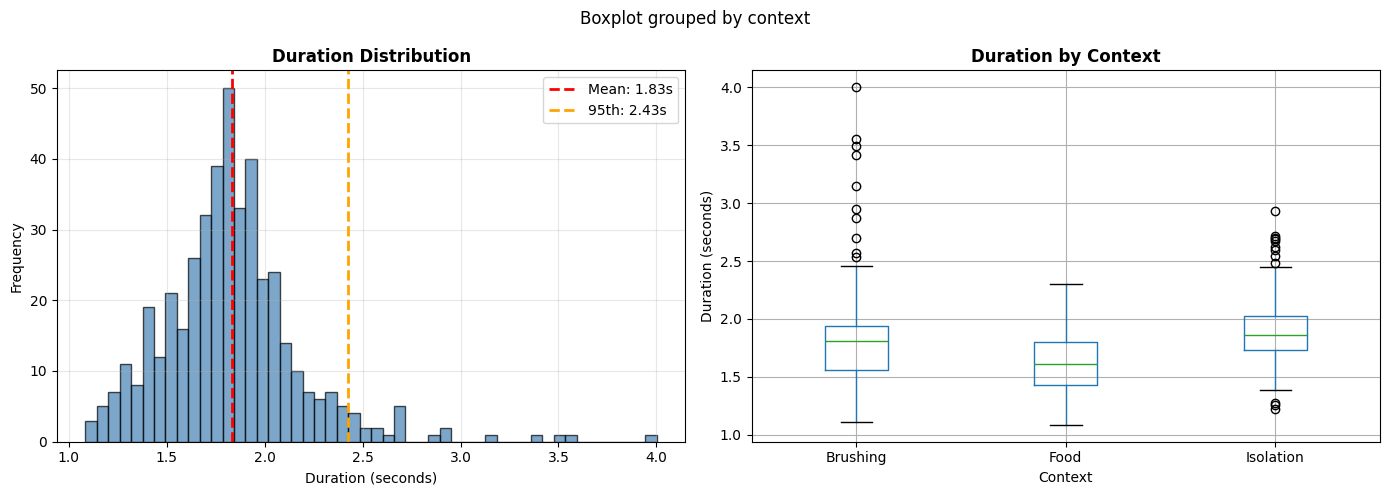


✓ Saved: preprocessing_01_duration_analysis.png

TARGET PARAMETERS
  Duration: 2.5 seconds
  Sample rate: 22050 Hz
  Length: 55,125 samples

Impact:
  Files to pad: 422 (95.9%)
  Files to truncate: 18 (4.1%)

✓ Saved metadata with durations


In [2]:
# DURATION ANALYSIS

print("=" * 70)
print("DURATION ANALYSIS")
print("=" * 70)

# Calculate durations if not in metadata
if 'duration' not in df.columns or df['duration'].isna().any():
    print("\nCalculating durations...")
    durations_list = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Loading durations"):
        try:
            y, sr = sf.read(row['file_path'])
            if len(y.shape) > 1:
                y = np.mean(y, axis=1)
            duration = len(y) / sr
            durations_list.append(duration)
        except Exception as e:
            print(f"  Error: {row['filename']}: {e}")
            durations_list.append(np.nan)

    df['duration'] = durations_list

durations = df['duration'].dropna()

# Statistics
print(f"\nDuration Statistics:")
print(f"  Count: {len(durations)}")
print(f"  Mean: {durations.mean():.3f}s")
print(f"  Median: {durations.median():.3f}s")
print(f"  Std: {durations.std():.3f}s")
print(f"  Min: {durations.min():.3f}s")
print(f"  Max: {durations.max():.3f}s")

percentiles = [50, 75, 90, 95, 99]
print(f"\nPercentiles:")
for p in percentiles:
    val = durations.quantile(p/100)
    print(f"  {p}th: {val:.3f}s")

# %%
# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(durations, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].axvline(durations.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {durations.mean():.2f}s')
axes[0].axvline(durations.quantile(0.95), color='orange', linestyle='--', linewidth=2,
                label=f'95th: {durations.quantile(0.95):.2f}s')
axes[0].set_xlabel('Duration (seconds)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Duration Distribution', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

df.boxplot(column='duration', by='context', ax=axes[1])
axes[1].set_title('Duration by Context', fontweight='bold')
axes[1].set_xlabel('Context')
axes[1].set_ylabel('Duration (seconds)')
plt.sca(axes[1])
plt.xticks([1, 2, 3], ['Brushing', 'Food', 'Isolation'])

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'preprocessing_01_duration_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: preprocessing_01_duration_analysis.png")

# %%
# Set target parameters
TARGET_DURATION = np.ceil(durations.quantile(0.95) * 2) / 2  # Round to 0.5s
TARGET_SR = 22050
TARGET_LENGTH = int(TARGET_DURATION * TARGET_SR)

print(f"\n{'='*70}")
print(f"TARGET PARAMETERS")
print(f"{'='*70}")
print(f"  Duration: {TARGET_DURATION} seconds")
print(f"  Sample rate: {TARGET_SR} Hz")
print(f"  Length: {TARGET_LENGTH:,} samples")
print(f"\nImpact:")
print(f"  Files to pad: {(durations < TARGET_DURATION).sum()} ({(durations < TARGET_DURATION).sum()/len(durations)*100:.1f}%)")
print(f"  Files to truncate: {(durations > TARGET_DURATION).sum()} ({(durations > TARGET_DURATION).sum()/len(durations)*100:.1f}%)")

# Save updated metadata
df.to_csv(DATA_DIR / "metadata_with_durations.csv", index=False)
print(f"\n✓ Saved metadata with durations")

TESTING PREPROCESSING PIPELINE

Test file: I_SPI01_EU_MN_NAI01_105.wav

Original:
  Sample rate: 8000 Hz
  Duration: 2.694s
  Samples: 21,555

✓ Preprocessing successful!

Processed:
  Sample rate: 22050 Hz
  Duration: 2.500s
  Samples: 55,125
  Shape: (55125,)
  Amplitude range: [-0.1557, 0.1608]
  Memory: 430.66 KB


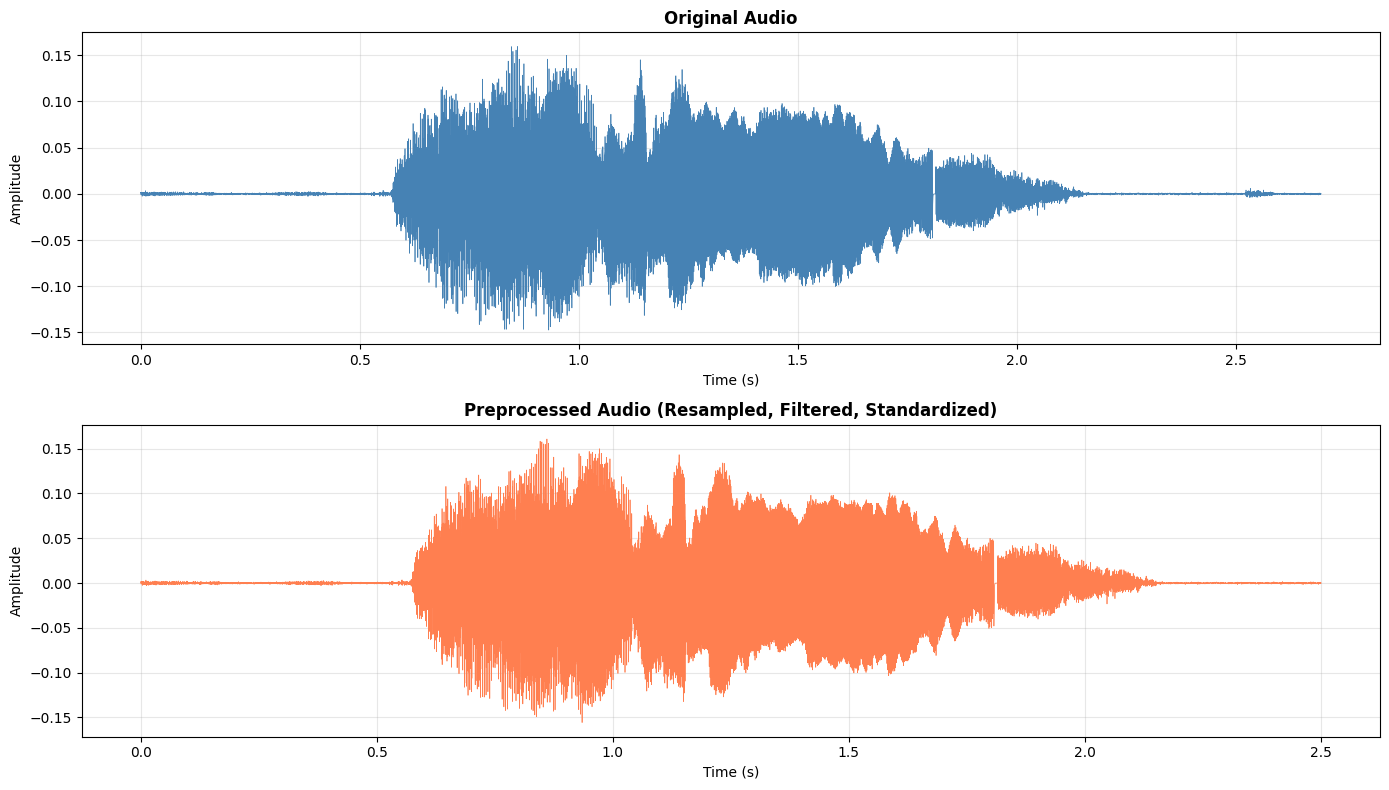


✓ Saved: preprocessing_02_pipeline_test.png


In [3]:
# PREPROCESSING FUNCTIONS (LIBROSA-FREE - it was giving me a headache)


def load_audio(file_path):
    """Load audio using soundfile (not librosa)."""
    y, sr = sf.read(file_path)

    # Convert stereo to mono if needed
    if len(y.shape) > 1:
        y = np.mean(y, axis=1)

    return y, sr

def resample_audio(y, orig_sr, target_sr=22050):
    """Resample using resampy."""
    if orig_sr == target_sr:
        return y

    y_resampled = resampy.resample(y, orig_sr, target_sr)
    return y_resampled

def apply_lowpass_filter(y, sr, cutoff_freq=4000, order=5):
    """Apply 4 kHz low-pass Butterworth filter."""
    nyquist = sr / 2
    normal_cutoff = cutoff_freq / nyquist

    # Design filter
    b, a = signal.butter(order, normal_cutoff, btype='low', analog=False)

    # Apply filter
    y_filtered = signal.filtfilt(b, a, y)

    return y_filtered

def standardize_duration(y, target_length):
    """Pad or truncate to target length."""
    current_length = len(y)

    if current_length < target_length:
        # Pad with zeros
        padding = target_length - current_length
        y = np.pad(y, (0, padding), mode='constant', constant_values=0)
    elif current_length > target_length:
        # Truncate
        y = y[:target_length]

    return y

def preprocess_audio_file(file_path, target_sr=TARGET_SR, target_length=TARGET_LENGTH):
    """
    Complete preprocessing pipeline (NO LIBROSA).

    Steps:
    1. Load with soundfile
    2. Resample to 22,050 Hz
    3. Apply 4 kHz low-pass filter
    4. Standardize duration
    5. Keep raw amplitude (no normalization)
    """
    try:
        # Load
        y, sr = load_audio(file_path)

        # Resample
        y = resample_audio(y, sr, target_sr)

        # Filter 0-4 kHz
        y = apply_lowpass_filter(y, target_sr, cutoff_freq=4000)

        # Standardize duration
        y = standardize_duration(y, target_length)

        # Verify
        assert len(y) == target_length, f"Length mismatch: {len(y)} != {target_length}"

        return y

    except Exception as e:
        print(f"  Error: {e}")
        return None

# %%
# Test preprocessing
print("=" * 70)
print("TESTING PREPROCESSING PIPELINE")
print("=" * 70)

test_file = df.sample(1).iloc[0]
print(f"\nTest file: {test_file['filename']}")

y_original, sr_original = load_audio(test_file['file_path'])
print(f"\nOriginal:")
print(f"  Sample rate: {sr_original} Hz")
print(f"  Duration: {len(y_original)/sr_original:.3f}s")
print(f"  Samples: {len(y_original):,}")

y_processed = preprocess_audio_file(test_file['file_path'])

if y_processed is not None:
    print(f"\n✓ Preprocessing successful!")
    print(f"\nProcessed:")
    print(f"  Sample rate: {TARGET_SR} Hz")
    print(f"  Duration: {len(y_processed)/TARGET_SR:.3f}s")
    print(f"  Samples: {len(y_processed):,}")
    print(f"  Shape: {y_processed.shape}")
    print(f"  Amplitude range: [{y_processed.min():.4f}, {y_processed.max():.4f}]")
    print(f"  Memory: {y_processed.nbytes / 1024:.2f} KB")

    # Visualize
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    # Original
    time_orig = np.linspace(0, len(y_original)/sr_original, len(y_original))
    axes[0].plot(time_orig, y_original, linewidth=0.5, color='steelblue')
    axes[0].set_title('Original Audio', fontweight='bold')
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('Amplitude')
    axes[0].grid(alpha=0.3)

    # Processed
    time_proc = np.linspace(0, len(y_processed)/TARGET_SR, len(y_processed))
    axes[1].plot(time_proc, y_processed, linewidth=0.5, color='coral')
    axes[1].set_title('Preprocessed Audio (Resampled, Filtered, Standardized)', fontweight='bold')
    axes[1].set_xlabel('Time (s)')
    axes[1].set_ylabel('Amplitude')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'preprocessing_02_pipeline_test.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n✓ Saved: preprocessing_02_pipeline_test.png")

else:
    print(f"\n Preprocessing failed")

In [4]:
# PROCESS ALL 440 FILES

print("=" * 70)
print("PREPROCESSING ALL FILES")
print("=" * 70)
print(f"\nTotal files: {len(df)}")
print(f"Estimated time: ~{len(df) * 2 / 60:.1f} minutes")
print("\nProcessing...")

processed_data = []
failed_files = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Preprocessing"):
    y_processed = preprocess_audio_file(row['file_path'])

    if y_processed is not None:
        # Save as numpy array
        output_filename = row['filename'].replace('.wav', '.npy')
        output_path = PROCESSED_DATA_DIR / output_filename
        np.save(output_path, y_processed)

        processed_data.append({
            'index': idx,
            'preprocessed_file_path': str(output_path),
            'preprocessed': True,
            'preprocessed_shape': y_processed.shape,
            'preprocessed_size_kb': y_processed.nbytes / 1024
        })
    else:
        failed_files.append(idx)
        processed_data.append({
            'index': idx,
            'preprocessed_file_path': None,
            'preprocessed': False,
            'preprocessed_shape': None,
            'preprocessed_size_kb': None
        })

    # Checkpoint every 100 files
    if (idx + 1) % 100 == 0:
        temp_df = pd.DataFrame(processed_data)
        temp_df.to_csv(DATA_DIR / f'checkpoint_{idx+1}.csv', index=False)

# %%
print(f"\n{'='*70}")
print("PREPROCESSING COMPLETE")
print(f"{'='*70}")

successful = len([p for p in processed_data if p['preprocessed']])
print(f"\n✓ Successfully preprocessed: {successful} files")
print(f" Failed: {len(failed_files)} files")

if len(failed_files) > 0:
    print(f"\nFailed indices: {failed_files[:10]}..." if len(failed_files) > 10 else failed_files)

# %%
# Create metadata
df_processed = pd.DataFrame(processed_data)
df_processed.set_index('index', inplace=True)
df_final = pd.concat([df, df_processed], axis=1)

# Save
final_path = DATA_DIR / "metadata_preprocessed.csv"
df_final.to_csv(final_path, index=False)

print(f"\n✓ Saved: {final_path}")

# %%
# Summary
print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)

successful_df = df_final[df_final['preprocessed'] == True]

print(f"\nPreprocessed Files:")
print(f"  Total: {len(successful_df)}")
if len(successful_df) > 0:
    print(f"  Shape: {successful_df['preprocessed_shape'].iloc[0]}")
    print(f"  Avg size: {successful_df['preprocessed_size_kb'].mean():.2f} KB")
    print(f"  Total size: {successful_df['preprocessed_size_kb'].sum() / 1024:.2f} MB")

print(f"\nBy Context:")
print(successful_df.groupby('context').size())

print(f"\nBy Distress Label:")
print(successful_df.groupby('distress_label').size())

print("\n✓ Ready for train/val/test split!")

PREPROCESSING ALL FILES

Total files: 440
Estimated time: ~14.7 minutes

Processing...


Preprocessing: 100%|██████████| 440/440 [05:18<00:00,  1.38it/s]


PREPROCESSING COMPLETE

✓ Successfully preprocessed: 440 files
 Failed: 0 files

✓ Saved: /content/drive/MyDrive/Electric Sheep/Beliz - EDA/data/metadata_preprocessed.csv

SUMMARY

Preprocessed Files:
  Total: 440
  Shape: (55125,)
  Avg size: 430.66 KB
  Total size: 185.05 MB

By Context:
context
B    127
F     92
I    221
dtype: int64

By Distress Label:
distress_label
0    219
1    221
dtype: int64

✓ Ready for train/val/test split!
